## Student Performance Analysis

### Data Loading and Initial Inspection
in this section, we:
- Import the necessary libraries
- Load the dataset
- Inspect the first few rows
- Examine column names and data types

In [73]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
# Load and inspect dataset
df = pd.read_csv("../data/raw/student_performance.csv")
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [75]:
# Let's check out the shape and data types
print(f"Shape: {df.shape}")
print("---------- Data Types ----------")
print(df.dtypes)

Shape: (1000, 12)
---------- Data Types ----------
StudentID                    float64
Name                             str
Gender                           str
AttendanceRate               float64
StudyHoursPerWeek            float64
PreviousGrade                float64
ExtracurricularActivities    float64
ParentalSupport                  str
FinalGrade                   float64
Study Hours                  float64
Attendance (%)               float64
Online Classes Taken          object
dtype: object


## Data Cleaning

                           missing_count  missing_pct
StudentID                             40          4.0
Name                                  34          3.4
Gender                                48          4.8
AttendanceRate                        40          4.0
StudyHoursPerWeek                     50          5.0
PreviousGrade                         33          3.3
ExtracurricularActivities             43          4.3
ParentalSupport                       22          2.2
FinalGrade                            40          4.0
Study Hours                           24          2.4
Attendance (%)                        41          4.1
Online Classes Taken                  25          2.5


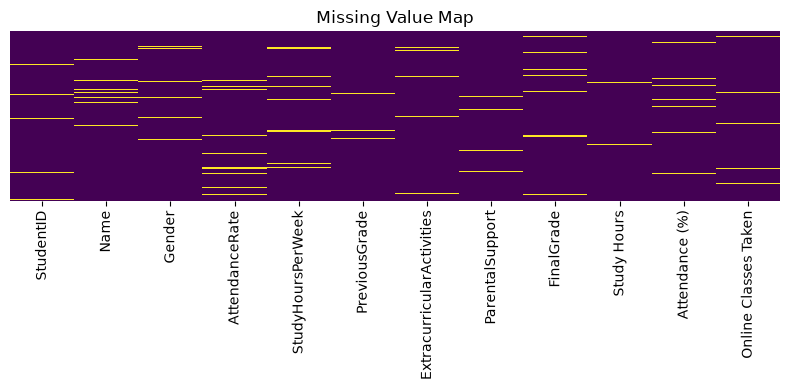

In [76]:
# Check for missing values
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_summary[missing_summary["missing_count"] > 0])

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing Value Map")
plt.tight_layout()
plt.savefig("../outputs/plots/01_missing_values.png", dpi=100)
plt.show()
plt.close()



In [77]:
# We now know that the missing datas are spread out across the datasets but let's confirm 
df.isnull().sum(axis=1).value_counts().sort_index()
df[df.isnull().sum(axis=1) >= 3]

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
117,7797.0,Angela Williams,NaN,85.0,22.0,60.0,2.0,High,NaN,1.1,78.0,NaN
184,6669.0,Ryan Williams,Female,90.0,18.0,90.0,NaN,NaN,68.0,3.1,89.0,NaN
197,3440.0,Brandon Williamson,Male,95.0,NaN,88.0,0.0,Medium,NaN,NaN,69.0,False
439,3979.0,Jonathan Mann,Female,78.0,NaN,77.0,3.0,Low,87.0,1.1,NaN,NaN
675,7672.0,NaN,Female,70.0,25.0,85.0,NaN,NaN,90.0,0.9,93.0,False


We can now see that the missing values are scattered across the datasets, if we decide to drop them, we will lose 275 data, so let'd decide what to do per-column.

If a row is missing **StudentID** and **Name**, it is still usable